# Abstract Classification
In this notebook we aim to develop a classification model regarding NLP. Our goal is to predict whether a given paper abstract concerns about Machine Learning.

In [ ]:
import pandas as pd
import numpy as np
import nltk
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import functions_aux as f
from joblib import dump, load
import visuals

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='white')


%load_ext autoreload
%autoreload 2

In [ ]:
brz_path = 'bronze/abs_classification'
slv_path = 'silver/abs_classification'
model_path = 'models/abs_classification'

In [ ]:
df = pd.read_json(f'{brz_path}/classified_abstracts.json')
df

## EDA and Feature Engineering
Firstly, we observe four duplicates and 1 missing value in DOI. We remove them all.

In [3]:
df = df.drop_duplicates(subset='DOI')
df.isnull().sum()

DOI         1
Abstract    0
Label       0
dtype: int64

In [4]:
df = df[~df['DOI'].isna()]

In [12]:
aux = df['Label'].value_counts()
display(aux)

display(aux / len(df))

Label
0    900
1    234
Name: count, dtype: int64

Label
0    0.793651
1    0.206349
Name: count, dtype: float64

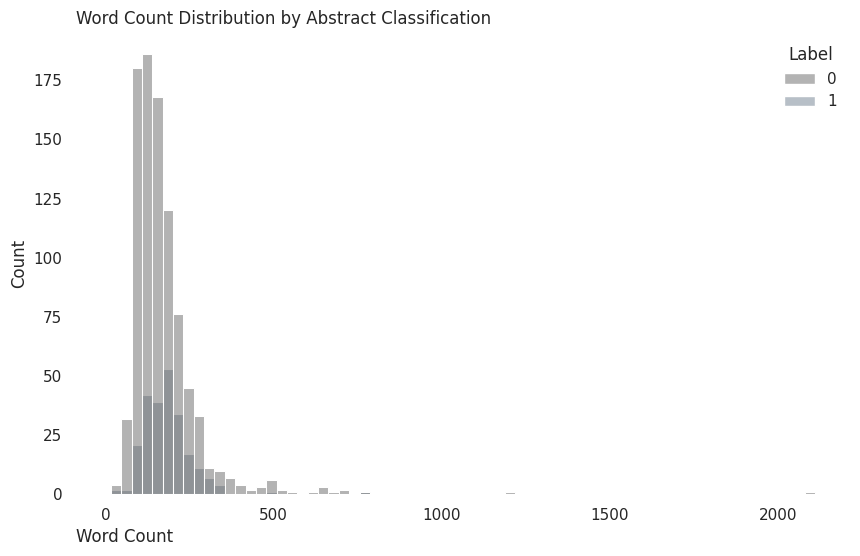

In [5]:
df['n_chars'] = df['Abstract'].str.len()  # number of characters, including blank space
df['word_count'] = df['Abstract'].str.split(' ').str.len()  # word count
df['Abstract'] = df['Abstract'].str.lower()


plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='word_count',
    hue='Label',
    palette=['dimgrey', 'slategrey']
)
plt.title(
    'Word Count Distribution by Abstract Classification',
    loc='left'
)
plt.xlabel('Word Count', loc='left')
plt.box(False)

## Baseline
As an immediate baseline, we can simply check if the abstract contains the string 'machine learning' and predict it as 1 if positive and 0 if negative. This way, we get 64 out of 234.

In [6]:
df['contains_ML'] = df['Abstract']\
    .str.contains('machine learning')\
    .astype(int)

df[['contains_ML', 'Label']].groupby('Label').sum()

,contains_ML
Label,
0,0
1,64


As we are dealing with a classification problem, it is interesting to consider metrics from the consufion matrix, such as recall, precision, F1, and accuracy. Particularly, since we have an imbalanced dataset (20% of positive values), we shall pay more attention to metrics that give more weight to the positive class, like precision, recall, and F1 score. Below is the confusion metrics for our baseline.

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
y_true = df['Label'].to_numpy()
y_pred = df['contains_ML'].to_numpy()

print(classification_report(
    y_true, y_pred,
    target_names=['0', '1']
))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       900
           1       1.00      0.27      0.43       234

    accuracy                           0.85      1134
   macro avg       0.92      0.64      0.67      1134
weighted avg       0.87      0.85      0.81      1134



In [ ]:
# cnfn_metrics = {}
# cnfn_metrics['baseline'] = f.get_confusion_metrics(df, 'Label', 'contains_ML')

# pd.DataFrame(cnfn_metrics)

From them, we get:

1. Only 27% of actual positives were caught (TPR = 0.27, also known as recall), meaning that we are only capturing 27% of all true positive abstracts
2. We never misclassified a negative as positive (TNR = 1, also known as specificity)
3. No false positives (FPR = 1 - TNR = 0; consistent with the keyword being overly strict)
4. Every positive we predicted really is one (PPV = 1, also known as precision), 
5. Good accuracy, but is inflated by class imbalance (ACC = 0.85; many negatives: support for class 0 corresponds to 79%)
6. 43% of F1 score for the positive class reflects the precision x recall trade-off, where low recall drags it down

### Stronger Baseline
The considerations above suggest that many abstracts refer to the positive class implicitly, through synonyms, like deep learning, artificial intelligence, predictive model, or related phrasing. We can thus extend our baseline to include such synonyms or related keywords.

In [8]:
df['contains_DL'] = df['Abstract']\
    .str.contains('deep learning')\
    .astype(int)

df['contains_NN'] = df['Abstract']\
    .str.contains('neural network')\
    .astype(int)

df['contains_AI'] = df['Abstract']\
    .str.contains('artificial intelligence')\
    .astype(int)

df['contains_PM'] = df['Abstract']\
    .str.contains('predictive model')\
    .astype(int)

df['baseline_pred'] = (
    df[[
        'contains_ML', 'contains_DL',
        'contains_NN', 'contains_AI',
        'contains_PM'
    ]].any(axis=1)
).astype(int)

df.head()

,DOI,Abstract,Label,n_chars,word_count,contains_ML,contains_DL,contains_NN,contains_AI,contains_PM,baseline_pred
0,10.1155/2021/1071145,forward-looking forecasting of the inflation r...,1,1502,211,0,1,1,0,1,1
1,10.1007/s43546-022-00384-2,our study examined the disaggregation of infla...,1,1218,188,1,0,0,0,0,1
2,10.1002/for.2667,this paper develops a dynamic factor model tha...,0,1083,156,0,0,0,0,0,0
3,10.1007/s42973-021-00091-x,"in this paper, i use a simple sir macro model ...",0,1251,194,0,0,0,0,0,0
4,10.1007/s40258-012-0003-z,backgroundgame theory is useful for identifyin...,0,1576,209,0,0,0,0,0,0


In [34]:
y_true = df['Label'].to_numpy()
y_pred = df['baseline_pred'].to_numpy()

print(classification_report(
    y_true, y_pred,
    target_names=['0', '1']
))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       900
           1       0.97      0.48      0.64       234

    accuracy                           0.89      1134
   macro avg       0.92      0.74      0.79      1134
weighted avg       0.90      0.89      0.87      1134



In [ ]:
# cnfn_metrics['baseline'] = f.get_confusion_metrics(df, 'Label', 'baseline_pred')
# pd.DataFrame(cnfn_metrics)

These new numbers show that nearly twice as many true positives are being caught (21 percentage points increase on TPR, now being 48%) with nearly perfect precision (97% of PPV). The former results on a massive gain on F1 score: from 43% to 64%.

This demonstrates that many relevant abstracts do not mention Machine Learning directly, but use related phrases. As FPR remains practically 0, our keywords show to be precise. In other words, still, we are now retrieving half of all true positives, with almost perfect precision. Our learned model now has a great baseline to beat.

Nevertheless, this is still a rule-based system, through lexical matching, as it does not understand semantics, only the exact phrase presence, and it cannot generalize to related terminology or implicitly Machine Learning usage. Regardless, it can be used as a first filter in a pipeline, to catch easy and obvious positives in an automatic labeling without human review scenario.

We end this section by saving our dataframe in the silver layer.

In [17]:
df.to_csv(f'{slv_path}/abs_classification.csv', index=False)

In [3]:
df = pd.read_csv(f'{slv_path}/abs_classification.csv')
df

,DOI,Abstract,Label,n_chars,word_count,contains_ML,contains_DL,contains_NN,contains_AI,contains_PM,baseline_pred
0,10.1155/2021/1071145,forward-looking forecasting of the inflation r...,1,1502,211,0,1,1,0,1,1
1,10.1007/s43546-022-00384-2,our study examined the disaggregation of infla...,1,1218,188,1,0,0,0,0,1
2,10.1002/for.2667,this paper develops a dynamic factor model tha...,0,1083,156,0,0,0,0,0,0
3,10.1007/s42973-021-00091-x,"in this paper, i use a simple sir macro model ...",0,1251,194,0,0,0,0,0,0
4,10.1007/s40258-012-0003-z,backgroundgame theory is useful for identifyin...,0,1576,209,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1129,10.1007/bf00123887,concluding remarkswhile the final version of t...,0,3689,538,0,0,0,0,0,0
1130,10.1093/acrefore/9780190625979.013.171,high-dimensional dynamic factor models have th...,0,3655,558,0,0,0,0,0,0
1131,10.1287/mnsc.2013.1812,"francesca gino, erin l. krupka, roberto a. web...",0,14076,2111,0,0,0,0,0,0
1132,10.2118/22022-pa,"summary eor projects, notably co2 floods, are ...",0,4496,695,0,0,0,0,0,0


## Pipeline: CountVectorizer + Logistic Regression
We now start the modeling process: a pipeline with `CountVectorizer` and Logistic Regression. It performs two main tasks: **i)** convert raw text into numerical features; and **ii)** train a linear classification model. For the first, `CountVectorizer` is a feature extraction tool that converts a collection of text documents into a matrix of word counts. It works by creating a vocabulary of $N$ unique words (tokens) and then, for each document, counting the occurences of each word to create a vector. It can also be configured to count sequence of $n$ words, known as $n$-grams, rather than just individual words. Additionally, one can set minimum and maximum thresholds for document frequency to filter out words that are too rare or too common. This is an important step because the algorithms cannot understand pure text, only numbers. Thus, when we apply `CountVectorizer`, we are transforming a sequence of words into a vector that they can process.

As an example, consider the following text sentence "Hello, my name is Matheus and this is my notebook!". `CountVectorizer` will represent each unique word (token) as a column: $$[\text{Hello}, \text{my}, \text{name}, \text{is}, \text{Matheus}, \text{this}, \text{notebook}],$$ and then count the number of appearance for each (note that we have removed the word "and" as it does not add meaning - it is called a stopword), so that our result will be $$[1, 2, 1, 2, 1, 1, 1].$$ In a document, where several sentences are present, we start by creating our vocabulary by considering the $N$ most frequent words of all sentences. Notice that *the order and context are ignored*: only their occurrence matters. For each sentence we thus end up with a $N$-dimensional vector such that, for a document with $M$ sentences, we get a $M \times N$ numerical matrix.

This numerical matrix now enters the Logistic Regression, a linear model commonly used for binary classification (abstract refers to Machine Learning?). It takes the word count features generated by the `CountVectorizer`, learns the weights for each word, indicating how strongly it contributes to predicting a specific class, outputs a probability that a document belongs to the positive class and, finally, a decision threshold, usually 0.5, is applied to assign the final class label.

This pipeline, which ensures text preprocessing and model training are chained together, such that the exact transformations are applied during training and testing while also preventing data leakage, serves as a strong and interpretable first model before transitioning to more complex approaches like TF-IDF or semantic embbedings like SBERT.

In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

### Train/Test Split
It would be interesting to consider a train/validation/test partition strategy, so as to use the validation set for hyperparameter tuning and/or decision threshold definition. Sadly, our dataset is small, with only 1134 entries with nearly 20% for the positive class. Hence, we will split our dataset into a train/test split with proportions 70%/30%.

<!-- As `train_test_split` only divides into two parts each time, we will create the splits in two stages. The first will split the 100% dataset into 85%/15%: 15% for the test set, `X_test` and `y_test`, and the remaining 85% into a temporary dataset, `X_temp`, `y_temp`, later to be spllited once again into the training and validation sets. Consider, however, that in order to obtain 15% of the *total* dataset, we must evaluate the new splitting ratio: $0.85x = 0.15$, to be $x \approx$ 0.1765. Therefore, we split `X_temp` and `y_temp` into two, training and validation sets, with `test_size` = 0.1765. -->

In [48]:
X = df['Abstract'].copy()
y = df['Label'].copy()


SEED = 1

# keep a holdout test set for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Training set size: 793
Test set size: 341


### Cross-Validation and GridSearchCV
To ensure that the model generalizes well and is not overfitting to the training set, we use cross-validation (CV) combined with `GridSearchCV` to optimize hyperparameters in a reliable and sistematic way, inside the Pipeline.

Cross-validation is a technique used to evaluate model performance more robustly by splitting the training data into $k$ subsets, also called folds, known as $k$-fold cross-validation. The training data is divided into $k$ equal parts, where the model is trained on $k-1$ folds and validated on the remaining fold. That is, in a 5-fold scenario, the model is trained using folds {1, 2, 3, 4} and validated on fold 5. This process repeats $k$ times such that, in the next sequence, the model is trained using folds {1, 2, 3, 5} and validated on fold 4, and so forth. The final performance is the average validation across all folds. Particularly, we use the `StratifiedKFold`, which ensures that each fold preserves the same proportion of classes as the original dataset, being specially important for imbalanced datasets.

`GridSearchCV`, by its turn, automates the process for finding the best hyperparameters. It defines a dictionary (key-value pairs) with hyperparameters to test such that, for each combination, the model is trained using cross-validation and evaluated using a scoring metric (in our case: f1-score). Afterwards, it selects the set of hyperparameters that yields the best average cross-validation score.

Through the combination CV + `GridSearchCV` we prevent overfitting, as the model is evaluated on several folds, and optimizes hyperparameters safely, since they are tuned only using training data (test set remains untouched). 

In [49]:
pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('lr', LogisticRegression(random_state=SEED, class_weight='balanced'))
])

param_grid = {
    'vect__ngram_range': [(1,1), (1,2)],          # unigrams or up to bigrams
    'vect__min_df': [1, 2, 5],                    # drop very rare tokens
    'vect__max_df': [0.9, 0.95, 1.0],             # drop very frequent tokens (as fraction)
    'vect__max_features': [5000, 10000, None],    # limit vocab size
    'vect__binary': [False, True],                # use presence/absence vs counts
    'lr__C': [0.1, 1.0, 5.0],                     # regularization inverse strength
    'lr__solver': ['liblinear', 'saga', 'lbfgs']  # optimization algorithm
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'lr__C': [0.1, 1.0, ...], 'lr__solver': ['liblinear', 'saga', ...], 'vect__binary': [False, True], 'vect__max_df': [0.9, 0.95, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [50]:
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'lr__C': 5.0, 'lr__solver': 'saga', 'vect__binary': True, 'vect__max_df': 0.9, 'vect__max_features': 5000, 'vect__min_df': 1, 'vect__ngram_range': (1, 2)}
Best CV F1: 0.7686518983302157


We save our model in the `model_path`.

In [51]:
best = grid.best_estimator_

dump(best, f'{model_path}/lr.pkl')

['models/abs_classification/lr.pkl']

To make sure it is working properly, we load it back and continue.

In [52]:
lr = load(f'{model_path}/lr.pkl')

To compare `CountVectorizer` with our baseline, we evaluate them both on the test set. We observe a major metrics improvement, specially for the positive class. This demonstrates that moving from a rule-based baseline to classical machine learning, with text vectorization, brings a massive performance improvement. It also shows that `CountVectorizer` with Logistic Regression can already learn useful patterns. Nevertheless, we are still missing out 30% of relevant data (TPR = 69%) so that we have room for further improvements. In fact, we will train a `TfidfVectorizer` next.

In [55]:
df_test = df[df.index.isin(X_test.index)]

y_pred = df_test['baseline_pred'].to_numpy()

print('Baseline on test set:')
print(classification_report(
    y_test, y_pred,
    target_names=['0', '1']
))


y_pred = lr.predict(X_test)
print('Learned model on test set:')
print(classification_report(
    y_test, y_pred,
    target_names=['0', '1']
))

Baseline on test set:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       271
           1       0.14      0.07      0.09        70

    accuracy                           0.72       341
   macro avg       0.46      0.48      0.46       341
weighted avg       0.65      0.72      0.68       341

Learned model on test set:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       271
           1       0.83      0.69      0.75        70

    accuracy                           0.91       341
   macro avg       0.87      0.82      0.85       341
weighted avg       0.90      0.91      0.90       341



In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

### Precision-Recall Curve
Before moving on to more sophisticated models, it is interesting to analyse the Precision-Recall (PR) curve for the model. Positive predicted values (PPV, also known as precision) cares about false positives, since $$\text{PPV} = \frac{\text{TP}}{\text{TP} + \text{FP}},$$ where TP and FP stand for true positive and false positive, respectively. A high PPV means a positive result is very likely to be correct, while a low PPV means a positive result is more likely to be a false positive. On the other hand, the true positive rate (TPR, also known as recall) cares about false negatives, for $$\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}},$$ where FN stands for false negatives, and they usually trade-off: if one lowers the decision threshold, one will classify more samples as positive, that is, by increasing recall (finding more true positives), one lowers precision (by catching more false positives).

The PR curve puts them together and is particularly useful in imbalanced situations (where the positive class is rare), since a model can achieve great ROC-AUC, simply by correctly classifying the majority class, while keeping its precision low, meaning that most predicted positives are actually incorrect. Hence, the PR curve directly focuses on how well the model can predict the minority class, by ignoring true negatives, which dominates in imbalance, and by telling us how reliable the positive predictions are. The area under the curve (called average precision) summarizes the trade-off.

In our case, do we prefer to catch all ML papers even if some are false alarms? That is the kind of question the PR curve helps one to answer. For example, we observe that PPV decreases linearly (at a constant rate) until TPR reaches approximately 70%. This means that one is losing confidence that the abstract is indeed about Machine Learning as more papers are being caught. Thus, we are classifying more abstracts as positive, but some will be incorrect. At the cost of a broader coverage (increasing TPR, by lowering threshold), we start introducing false positives and, thus, PPV starts to drop.

When choosing to optimize F1-score, we are balancing between automation and discovery: a good balance between coverage and correctness.

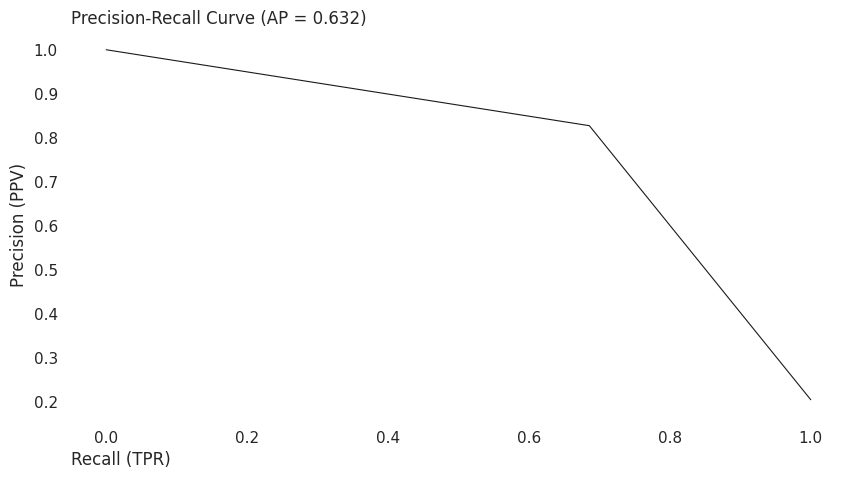

In [57]:
ppvs, tprs, thresholds = precision_recall_curve(y_test, y_pred)
avg_p = average_precision_score(y_test, y_pred)

plt.plot(tprs, ppvs, color='k', lw=.8)
plt.title(f'Precision-Recall Curve (AP = {avg_p:.3f})', loc='left')
plt.xlabel('Recall (TPR)', loc='left')
plt.ylabel('Precision (PPV)')
plt.box(False)

## Pipeline with TfidfVectorizer
`TfidfVectorizer` is an extension of `CountVectorizer`, which just consider the term frequencies (TF), so as to consider the inverse document frequency (IDF). It assigns more weight to words that occur frequently in a single document, but are rare across other documents (highlights informative words). In our case, classifying abstracts, `TfidfVectorizer` should be superior since abstracts share a lot of general terms like "data", "model", "paper", "study", "analysis", that would otherwise inflate counts (they will now be downweighted) while "learning" and "regression" will be upweighted. In summary, `CountVectorizer` represents word counts, sensitive to document length, whereas `TfidfVectorizer` represents a normalized weighted importance.

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [59]:
pipeline = Pipeline([
    ('tfvect', TfidfVectorizer(stop_words='english')),
    ('lr', LogisticRegression(random_state=SEED, class_weight='balanced'))
])

param_grid = {
    'tfvect__ngram_range': [(1,1), (1,2)],          # unigrams or up to bigrams
    'tfvect__min_df': [1, 2, 5],                    # drop very rare tokens
    'tfvect__max_df': [0.9, 0.95, 1.0],             # drop very frequent tokens (as fraction)
    'tfvect__max_features': [5000, 10000, None],    # limit vocab size
    'tfvect__binary': [False, True],                # use presence/absence vs counts
    'tfvect__sublinear_tf': [False, True],          # use sublinear tf scaling (smooths large term frequencies)
    'lr__C': [0.1, 1.0, 5.0],                     # regularization inverse strength
    'lr__solver': ['liblinear', 'saga', 'lbfgs']  # optimization algorithm
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'lr__C': [0.1, 1.0, ...], 'lr__solver': ['liblinear', 'saga', ...], 'tfvect__binary': [False, True], 'tfvect__max_df': [0.9, 0.95, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [60]:
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'lr__C': 5.0, 'lr__solver': 'saga', 'tfvect__binary': True, 'tfvect__max_df': 1.0, 'tfvect__max_features': 5000, 'tfvect__min_df': 1, 'tfvect__ngram_range': (1, 2), 'tfvect__sublinear_tf': False}
Best CV F1: 0.7707382247552891


In [61]:
best = grid.best_estimator_

dump(best, f'{model_path}/lr_tfidf.pkl')

['models/abs_classification/lr_tfidf.pkl']

Saving the `TfidfVectorizer` version in `model_path`...

In [65]:
lr_tf = load(f'{model_path}/lr_tfidf.pkl')

We are now able to compare both Vectorizer versions with one another. `TfidfVectorizer` presents a small, but meaningful, improvement over `CountVectorizer`, with 4 p.p. over precision for the positive class, a slightly decrease in recall (2 p.p.) and the best f1-score: 76%. This means that `TfidfVectorizer` improves the reliability of positive predictions (fewer false positives), while maintaing a similar recall.

Even tough we have a strong lexical model, we are still leaving out 1/3 of the relevant abstracts, being our key metric to improve next.

In [66]:
df_test = df[df.index.isin(X_test.index)]

y_pred = df_test['baseline_pred'].to_numpy()

print('Baseline on test set:')
print(classification_report(
    y_test, y_pred,
    target_names=['0', '1']
))


y_pred = lr.predict(X_test)
print('CountVectorizer model on test set:')
print(classification_report(
    y_test, y_pred,
    target_names=['0', '1']
))


y_pred = lr_tf.predict(X_test)
print('TfidfVectorizer model on test set:')
print(classification_report(
    y_test, y_pred,
    target_names=['0', '1']
))

Baseline on test set:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       271
           1       0.14      0.07      0.09        70

    accuracy                           0.72       341
   macro avg       0.46      0.48      0.46       341
weighted avg       0.65      0.72      0.68       341

CountVectorizer model on test set:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       271
           1       0.83      0.69      0.75        70

    accuracy                           0.91       341
   macro avg       0.87      0.82      0.85       341
weighted avg       0.90      0.91      0.90       341

TfidfVectorizer model on test set:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       271
           1       0.87      0.67      0.76        70

    accuracy                           0.91       341
   macro avg       0.90      0.82   

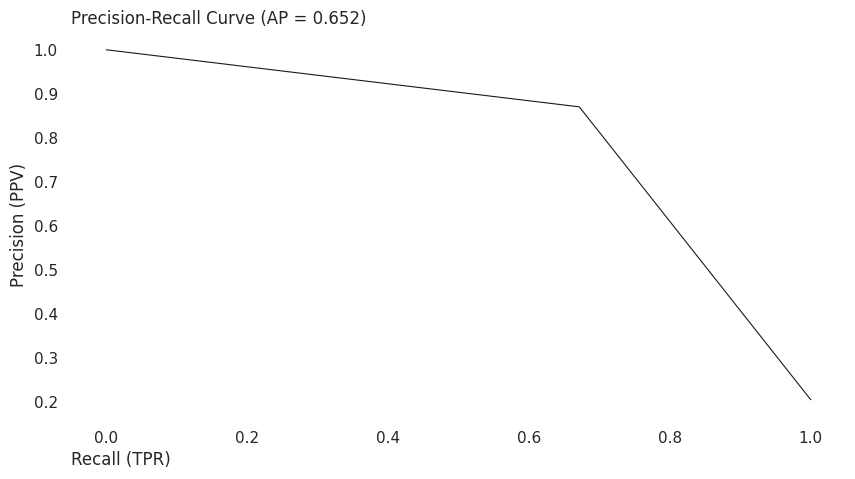

In [67]:
ppvs, tprs, thresholds = precision_recall_curve(y_test, y_pred)
avg_p = average_precision_score(y_test, y_pred)

plt.plot(tprs, ppvs, color='k', lw=.8)
plt.title(f'Precision-Recall Curve (AP = {avg_p:.3f})', loc='left')
plt.xlabel('Recall (TPR)', loc='left')
plt.ylabel('Precision (PPV)')
plt.box(False)

## Large Language Model: Sentence-BERT (SBERT)
To move beyond purely lexical representations like `CountVectorizer` and `TfidfVectorizer`, we adopt a semantic approach using SBERT followed by Logistic Regression for classification. This approach enables the model to understand the *meaning* of a sentence, through dense vectors (300+ dimensions), rather than relying only on word frequency or exact keyword matches. These vectors capture semantic meaning, allowing the model to recognize similar ideas even if different words are used. For instance, "we train a neural classifier" and "a machine learning model was developed" will have similar meaning, even if they share no exact words.

We will use a pre-trained model `SentenceTransformer("all-MiniLM-L6-v2")` and simply "tune it" to our task. Each abstract (contained in `X_train` and `X_test`) will be transformed into a semantic vector using `.encode()` that will serve as input to the Logistic Regression which, by its turn, will learn decision boundaries based on those semantic meanings.

In [69]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

In [ ]:
sbert = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = sbert.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_emb = sbert.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True
)

Batches: 100%|██████████| 11/11 [00:25<00:00,  2.35s/it]


In [77]:
lr = LogisticRegression(max_iter=5000, class_weight="balanced")
lr.fit(X_train_emb, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


We notice that SBERT has the highest f1-score and significantly improves recall, meaning it finds more true positive abstracts, even when Machine Learning is implied, while maintaing good precision. From this, we can conclude that semantics is playing a crucial role in detecting the positive class.

In [78]:
y_pred = lr.predict(X_test_emb)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       271
           1       0.71      0.86      0.77        70

    accuracy                           0.90       341
   macro avg       0.83      0.88      0.85       341
weighted avg       0.91      0.90      0.90       341



### Precision-Recall Curve
The PR curve has very similar shape and average precision value, altought slighly higher than the `TfidfVectorizer` case.

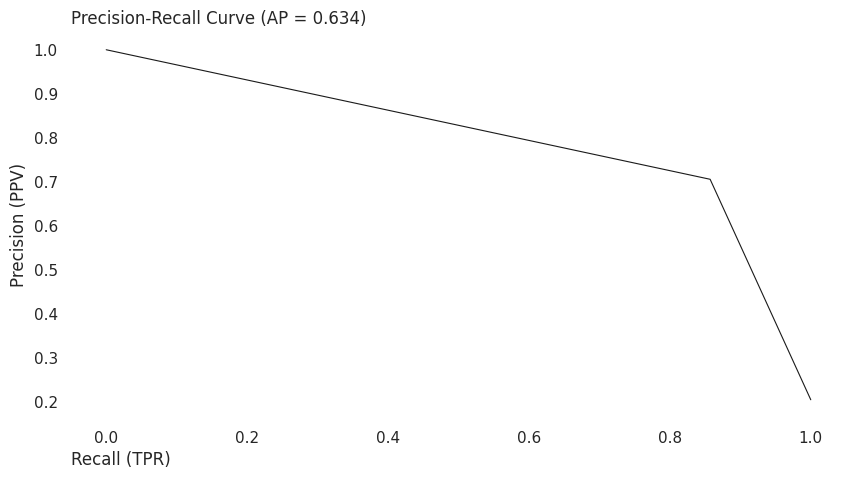

In [79]:
ppvs, tprs, thresholds = precision_recall_curve(y_test, y_pred)
avg_p = average_precision_score(y_test, y_pred)

plt.plot(tprs, ppvs, color='k', lw=.8)
plt.title(f'Precision-Recall Curve (AP = {avg_p:.3f})', loc='left')
plt.xlabel('Recall (TPR)', loc='left')
plt.ylabel('Precision (PPV)')
plt.box(False)

## Conclusion
This project addressed a binary text classification task: identifying whether an abstract is related to Machine Learning. We followed a structured, incremental approach, starting from simple baselines and moving toward more sophisticated NLP techniques, such as `CountVectorizer`, `TfidfVectorizer` and SBERT.

Baseline rule-based methods, like keyword matching ("machine learning", "artificial intelligence", etc), established an interpretable starting point. It achieved high precision, but very low recall, missing most relevant cases. We then moved to classical Machine Learning with `CountVectorizer` + Logistic Regression, significantly improving performance with balanced precision and recall. Next, we addressed `TfidfVectorizer` + Logistic Regression, further refining results by emphasizing more informative terms, slighly improving f1-score. Finally, we moved to semantic embbedings with SBERT + Logistic Regression, which delivered the best overall model. For the positive class we obtained 86% of recall (the model successfully detects most relevant abstracts) and 77% of f1-score. This progression demonstrates the beneft of evolving from lexical to semantic representation in NLP classification tasks.

This project has showed how combining traditional Machine Learning with modern language models leads to robust solutions in text classification. By following a step-by-step, metric-drive process, we ensured that every model improvement was justified and explainable.

The final SBERT model represents a strong balance between semantic understanding, performance, and interpretability, providing a solid foundation for further experimentation or deployment.

### Next Steps
To further improve the system, we can:
- perform threshold tuning using validation data to balance precision and recall, with the purpose of optimizing performance for real-world use
- realize error analysis, to analyse false cases (negatives and positives) especially those misclassified by SBERT, to identify patterns the model still does not understand
- try alternative classifiers such as SVM, XGBoost or Light GBM